# Predictive-campaign training dynamics: did every run train, and what does each objective cost?

This notebook validates the predictive-heads campaign before any of its prediction or
reconstruction results are interpreted, and measures how much wall time each objective
variant adds relative to the historical baseline. It answers two questions: whether every
run trained without a numerical failure or an early stop, and what each loss family costs
per epoch relative to the pre-existing baseline model. No model weights are loaded here;
everything is read from the campaign's recorded manifests and training histories.

It is a precondition for `part_1` through `part_6` (reconstruction, latent geometry and
prediction): a run whose training failed must not be read as a result, and a cost
difference of several times baseline is itself relevant to any decision about which
objective to adopt.

## Introduction

Two sources are pooled. `predictive_initial` is the swept campaign: one convolutional
encoder/decoder backbone (`conv1d-ae-32-16-8-latent-10`), 8 declared objective conditions
that each activate exactly one classification-head loss (masked and positive-weighted
multi-label BCE variants, a three-state cross-entropy PNU head, a variational PU bound and
a symmetric PU ranking loss), each declared for 5 repetitions differing only in run seeds.
`historical_bce` is a single, separately trained baseline model from an earlier campaign,
used as the comparison point from `part_4` onward; it is not a repetition of the swept
grid and shares no run seeds with it.

### Assumptions

- **Run comparability within the swept grid.** The 8 `predictive_initial` conditions
  share one backbone, one dataset contract and one split; only the classification-head
  loss and its positive-weighting mode differ. `campaign.inventory` verifies this by
  fingerprinting the saved data/backbone/training contracts and rejecting a run whose
  saved configuration does not match its manifest.
- **The baseline is a cross-source comparison, not a repetition.** `historical_bce` was
  trained in a different campaign. Pairing it against `predictive_initial` conditions
  (`part_4` onward) compares two independently seeded runs, not a paired repetition; no
  seed-matched contrast is available for it in this notebook.
- **Timing is wall-clock on shared hardware.** Epoch durations were recorded on compute
  nodes whose load is not controlled by this analysis. The comparison across conditions is
  only trustworthy to the extent it is consistent across every repetition of a condition,
  which contention would not reproduce.
- **Health checks are necessary, not sufficient.** A run that passes every check below can
  still have converged to a poor representation; that question belongs to the
  reconstruction, geometry and prediction notebooks that follow.

### Notation

Let $c$ index one of the 8 declared `predictive_initial` conditions and $r \in \{1,\dots,5\}$
one of its repetitions. For run $(c, r)$, write $L_e(c, r)$ for the recorded total training
loss at epoch $e$ and $T_e(c, r)$ for that epoch's wall-clock duration in seconds. $E(c, r)$
denotes the measured epoch count.

In [1]:
import json
import os
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

current_path = Path.cwd().resolve()
repository_root = next(path for path in (current_path, *current_path.parents) if (path / "pyproject.toml").is_file())
os.chdir(repository_root)

from msi_autoencoder_wrapper.analysis.autoencoder.experiments import predictive_campaign as campaign
from msi_autoencoder_wrapper.analysis.autoencoder.experiments import predictive_precompute as precompute
from msi_autoencoder_wrapper.utils.logger import get_custom_logger
from msi_autoencoder_wrapper.visualization import resolve_theme
from msi_autoencoder_wrapper.visualization.metrics import plot_violin_with_points

logger = get_custom_logger("campaign_training_dynamics")

2026-09-16 21:07:48,290 | INFO     | msi_autoencoder_wrapper.utils.module_search:79 | Discovered 1 implementation module(s) in package 'msi_autoencoder_wrapper.binners.binners_strategies'.
2026-09-16 21:07:48,293 | INFO     | msi_autoencoder_wrapper.utils.module_search:79 | Discovered 6 implementation module(s) in package 'msi_autoencoder_wrapper.binners.inverse_strategies'.
2026-09-16 21:07:49,535 | INFO     | msi_autoencoder_wrapper.utils.module_search:79 | Discovered 3 implementation module(s) in package 'msi_autoencoder_wrapper.models.architectures.types.autoencoders.presets'.
2026-09-16 21:07:49,537 | INFO     | msi_autoencoder_wrapper.utils.module_search:79 | Discovered 28 implementation module(s) in package 'msi_autoencoder_wrapper.models.architectures.types.autoencoders'.
2026-09-16 21:07:49,543 | INFO     | msi_autoencoder_wrapper.utils.module_search:79 | Discovered 0 implementation module(s) in package 'msi_autoencoder_wrapper.models.architectures.types.schema'.
2026-09-16 21

## Configuration

## Producing the tables this notebook reads

### Methodology

#### Implementation

No model is loaded here. Reading and flattening the campaign's manifests and training
histories is nevertheless the one step that scales with the campaign size, so it is
precomputed like the rest.

That work lives in `predictive_precompute.campaign_training_dynamics`, is configured by
`analysis_settings.yaml` next to this notebook, and writes its tables to this notebook's
results directory. The health checks and the duration reduction are computed there too,
since both are functions of the same per-epoch records.

Run it once, detached, with the command printed below. It refuses to start on the
processor unless explicitly allowed. The command is generated by the runner itself, so
the instruction cannot drift from the entry point it describes.

Everything after this section reads those tables, which is why re-running this notebook
takes seconds.

### Remarks

### Notes

In [ ]:
from msi_autoencoder_wrapper.analysis.precompute.cli import run_precompute_command
SETTINGS_PATH = Path("assets/experiments/autoencoder_architecture/notebooks/segmentation_model/16_09_26_metaspace_heads_vpu/analysis_settings.yaml")
ANALYSIS = "campaign_training_dynamics"

settings = campaign.load_settings(SETTINGS_PATH)
settings["settings_path"] = str(SETTINGS_PATH)
analysis_settings = precompute.analysis_settings(settings, ANALYSIS)
ARTIFACT_DIR = analysis_settings["output_directory"]

# Seeds and the epoch budget come from the settings file, so the notebook and the
# precompute cannot drift apart on them.
SAMPLE_SEED = int(settings["sample_seed"])
PLANNED_EPOCHS = int(analysis_settings["planned_epochs"])

theme = resolve_theme(None)
theme.apply()

# --- embedded figure resolution --------------------------------------------
# Inline figures are stored inside the notebook as PNG. Rendering them at 100
# dpi instead of the theme's 140 roughly halves the stored size, leaving figure
# geometry and font proportions untouched.
FIGURE_RASTER_DPI = 100
plt.rcParams["savefig.dpi"] = FIGURE_RASTER_DPI
# ---------------------------------------------------------------------------

print("Run the precompute once, in the background:")
print(f"  {run_precompute_command(SETTINGS_PATH)}")
print("\nOr in the foreground, to watch it:")
print(f"  {run_precompute_command(SETTINGS_PATH, background=False)}")

In [3]:
# Tables produced by the command above; `load_analysis_table` reports the command again
# if one is missing, so a fresh checkout fails with an instruction rather than a stack
# trace.
inventory = precompute.load_analysis_table(settings, ANALYSIS, "inventory")
sources_frame = precompute.load_analysis_table(settings, ANALYSIS, "sources")
coverage_frame = precompute.load_analysis_table(settings, ANALYSIS, "condition_coverage")
dynamics_frame = precompute.load_analysis_table(settings, ANALYSIS, "training_dynamics")
evaluation_frame = precompute.load_analysis_table(settings, ANALYSIS, "final_evaluation")
health_frame = precompute.load_analysis_table(settings, ANALYSIS, "training_health")
run_frame = precompute.load_analysis_table(settings, ANALYSIS, "run_durations")

provenance = precompute.load_analysis_metadata(settings, ANALYSIS)

print(f"{len(inventory)} model(s) across {sources_frame.source.nunique()} source(s), "
     f"{len(dynamics_frame)} per-epoch record(s)")
print(f"precomputed at commit {provenance['git_commit']} on {provenance['settings']['device']}")

65 model(s) across 3 source(s), 9525 per-epoch record(s)
precomputed at commit e3b8aef6c9ee49acda5d35c416410af769df41bc on cuda


## Campaign coverage

### Methodology

#### Theoretical

Every downstream comparison assumes each declared condition contributes the same number
of repetitions. A condition short of repetitions is not merely noisier: pooled statistics
across conditions become weighted by an accident of which runs finished. This section
establishes the realized design before anything is compared, separately for the swept
grid and for the baseline.

#### Implementation

`predictive_campaign.configured_grid` reads the declared (architecture, objective) cells
from the campaign configuration; `predictive_campaign.coverage_table` compares each
declared condition's expected task and seed count against what `predictive_campaign.inventory`
found downloaded and ready in the `predictive_initial` source. The baseline source has no
declared grid of its own, so its readiness is read directly from the inventory instead.

#### Figure descriptions

The first table lists one row per declared `predictive_initial` condition: its label, how
many tasks and matched seeds are declared versus downloaded and ready, and whether seed
coverage is complete. The second table lists every source's row count and how many of its
models are `ready` (completed, weights present, saved configuration matching its
manifest).

### Remarks

### Notes

In [4]:
display(coverage_frame[["label", "declared_cells", "expected_tasks", "expected_seeds",
                        "downloaded_tasks", "ready_tasks", "ready_seeds", "complete_seed_coverage"]])

incomplete = coverage_frame[~coverage_frame["complete_seed_coverage"]]
print("conditions with incomplete seed coverage:", len(incomplete))

readiness = inventory.groupby("source").agg(models=("model_id", "size"), ready=("ready", "sum")).reset_index()
display(readiness.merge(sources_frame[["source", "available"]], on="source"))

,label,declared_cells,expected_tasks,expected_seeds,downloaded_tasks,ready_tasks,ready_seeds,complete_seed_coverage
0,vpu_alpha_1_5_beta_1 (VariationalPULoss),1,5,5,0,0,0,False
1,vpu_alpha_2_beta_1 (VariationalPULoss),1,5,5,0,0,0,False
2,vpu_alpha_1_beta_1 (VariationalPULoss),1,5,5,0,0,0,False
3,vpu_alpha_1_25_beta_1 (VariationalPULoss),1,5,5,0,0,0,False
4,vpu_alpha_3_beta_1 (VariationalPULoss),1,5,5,0,0,0,False


conditions with incomplete seed coverage: 5


,source,models,ready,available
0,historical_bce,5,5,True
1,predictive_initial,10,10,True
2,vpu_precision_sweep,50,50,True


## Training validity per run

### Methodology

#### Theoretical

Four independent failure modes would each invalidate a run's results in a different way,
and none is visible in a final metric alone:

1. a non-finite value at any logged epoch means the optimizer left the valid region and
   every later epoch is meaningless;
2. a final training total loss $L_{E}$ exceeding the first epoch's $L_1$ means the
   objective was not actually minimized over the run;
3. fewer measured epochs than the configured budget, $E < E_{\mathrm{planned}}$, means
   early stopping or a crash;
4. no improving validation checkpoint after the first epoch means the restored best model
   is the first epoch's, so the run effectively did not train.

Run $(c, r)$ is flagged unhealthy if any of $\exists e: \neg\mathrm{finite}(L_e)$,
$L_{E}>L_{1}$, $E < E_{\mathrm{planned}}$, or no improving checkpoint exists for $e>1$.

#### Implementation

`predictive_campaign.training_health_report` computes all four checks from the per-epoch
records, keyed by `model_id`. There is no single scalar "penalty" term in a predictive
objective the way there is in the contractive campaigns, so the check that there examines
the penalty's own trajectory is replaced here by the same finiteness/monotonicity logic
applied to the total training loss.

#### Figure descriptions

The first table counts flagged runs per source: one column per check plus the count of
runs passing all four. Zero in every check column and a `healthy` count equal to the
source's run count is the passing outcome. The second table, printed only when something
failed, lists each flagged run with its condition label, repetition, measured epoch count
and first/final total training loss.

### Remarks

### Notes

In [5]:
check_columns = ["non_finite_objectives", "loss_increased", "short_run", "no_improvement", "healthy"]
display(health_frame.groupby("source")[check_columns].sum())

unhealthy = health_frame[~health_frame["healthy"]]
if len(unhealthy):
    display(unhealthy[["source", "label", "repetition", "epochs", "first_total_loss", "final_total_loss", *check_columns[:-1]]])
else:
    print(f"All {len(health_frame)} run(s) passed every check.")

,non_finite_objectives,loss_increased,short_run,no_improvement,healthy
source,,,,,
historical_bce,0,0,0,0,5
predictive_initial,0,0,0,0,10
vpu_precision_sweep,0,0,0,0,50


All 65 run(s) passed every check.


## Training-loss trajectory within each run

### Methodology

#### Theoretical

The health check above only asks whether the total training loss decreased between the
first and last epoch. Its trajectory carries more: a loss that collapses within one epoch
and then sits flat indicates the run converged early, while one that decreases steadily
throughout indicates optimization remained active for the whole run. Because different
objectives are not on a common scale (a masked BCE, a variational PU bound and a
three-state cross-entropy do not share units), each run is normalized by its own
first-epoch value, $\tilde L_e = L_e / L_1$, which makes the *shape* comparable across
objectives while discarding the level, which is not.

#### Implementation

Training-split `total_loss` rows are divided by their own run's epoch-1 value. Every
repetition is drawn as its own line at low opacity rather than as a mean curve, so a
single divergent repetition inside an otherwise well-behaved condition stays visible. One
panel per declared `predictive_initial` condition; the baseline (a single run, not a
repeated condition) is excluded from this panel view and is instead part of the duration
comparison below.

#### Figure descriptions

One panel per `predictive_initial` condition. The x-axis is the training epoch, the
y-axis the total training loss normalized to its own first epoch, on a logarithmic scale.
Each thin line is one repetition. The dotted horizontal line at 1 marks the first-epoch
level: a line below it has reduced the loss, one above it has increased it.

### Remarks

### Notes

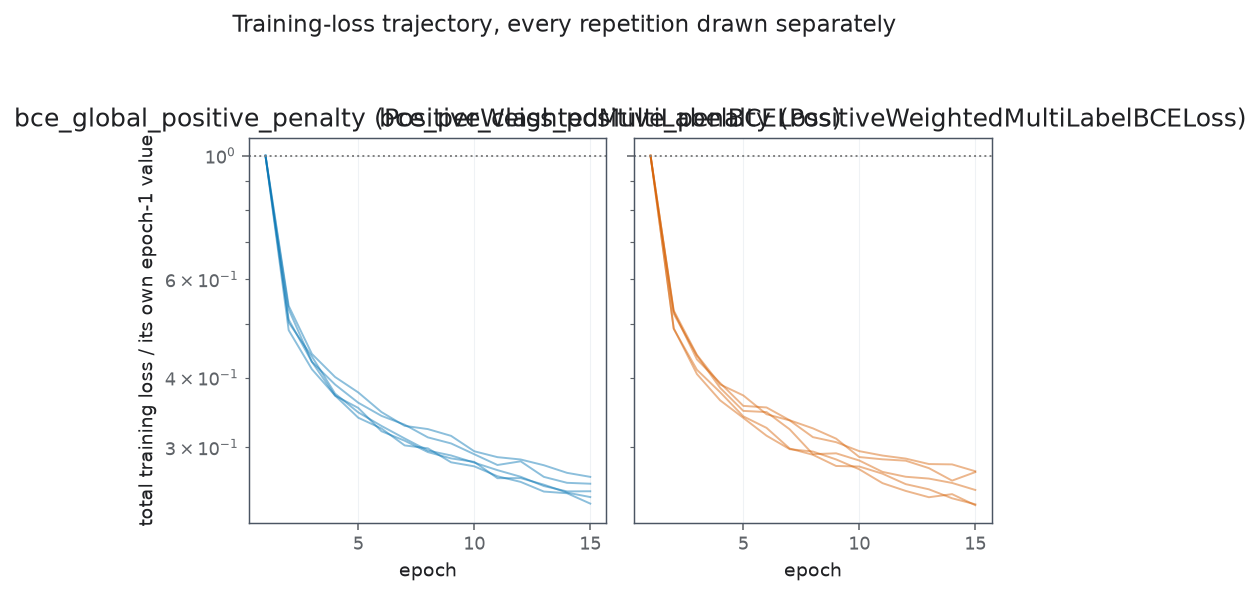

In [6]:
loss_curves = dynamics_frame.query("metric == 'total_loss' and history_split == 'train'").copy()
loss_curves = loss_curves.merge(inventory[["model_id", "source", "condition"]], on="model_id", validate="many_to_one")
loss_curves = loss_curves[loss_curves.source == "predictive_initial"]
first_epoch = loss_curves.query("epoch == 1").set_index("model_id")["value"]
loss_curves["normalized"] = loss_curves["value"] / loss_curves["model_id"].map(first_epoch)

conditions = loss_curves.drop_duplicates("condition")[["condition", "label"]].sort_values("label").reset_index(drop=True)
figure, axes = plt.subplots(1, len(conditions), figsize=(3.2 * len(conditions), 4.0), dpi=theme.figure_dpi, sharey=True)
for index, row in conditions.iterrows():
    axis = np.atleast_1d(axes)[index]
    family = loss_curves.query("condition == @row.condition")
    for model_id, run in family.groupby("model_id"):
        axis.plot(run["epoch"], run["normalized"], color=theme.color_for_model(row.label, index), alpha=0.45, linewidth=1.0)
    axis.axhline(1.0, color="grey", linestyle=":", linewidth=1)
    axis.set_yscale("log")
    axis.set(xlabel="epoch", title=row.label)
    axis.grid(theme.grid_visible, alpha=theme.grid_alpha)
np.atleast_1d(axes)[0].set_ylabel(r"total training loss / its own epoch-1 value")
figure.suptitle("Training-loss trajectory, every repetition drawn separately", y=1.05)
figure.tight_layout()

## Wall-clock cost of each condition

### Methodology

#### Theoretical

An objective's cost is a decision criterion, not an implementation detail: a loss that
doubles training time must earn that. Per-epoch duration $T_e(c, r)$ is treated as the
observation unit and pooled over epochs and repetitions within a condition. The reference
is the baseline model's own mean epoch duration $\bar T_{\mathrm{baseline}}$, and the
reported ratio is $\bar T_c / \bar T_{\mathrm{baseline}}$.

#### Implementation

`predictive_campaign.run_duration_frame` deduplicates the per-epoch `duration` bookkeeping
record on `(model_id, epoch)` before reducing, since the long-form history layout can log
the same epoch's duration once per logged phase. `predictive_campaign.epoch_duration_samples`
performs the same deduplication without reducing, so the violin plot below still draws
every measured epoch. Durations come from the trainer's own per-epoch `duration` field.

#### Figure descriptions

The table reports, per condition (baseline included), the mean and standard deviation of
individual epoch durations in seconds, the mean total duration of one complete run, and
the ratio of the condition's mean epoch duration to the baseline's. The violin plot shows
the full distribution of individual epoch durations for every condition, with each
measured epoch drawn as a point over the violin; the dotted horizontal line marks the
baseline mean.

### Remarks

Predictive objectives declare no analogous Jacobian-estimation method the way the
contractive penalties' `calculation_method` does, so there is no equivalent "declared
estimator vs. measured cost" check here: cost differences are attributed to the loss
family directly.

### Notes

In [7]:
baseline_epoch_seconds = run_frame.query("source == 'historical_bce'")["mean_epoch_duration"].mean()

duration_summary = (
    run_frame
    .groupby(["source", "condition", "label"], dropna=False)
    .agg(mean_epoch_seconds=("mean_epoch_duration", "mean"), std_epoch_seconds=("mean_epoch_duration", "std"),
        mean_total_seconds=("total_duration", "mean"), runs=("model_id", "size"))
    .reset_index()
)
duration_summary["times_baseline"] = duration_summary["mean_epoch_seconds"] / baseline_epoch_seconds
print(f"baseline mean epoch duration: {baseline_epoch_seconds:.1f} s")
display(duration_summary.round(2))

baseline mean epoch duration: 28.4 s


,source,condition,label,mean_epoch_seconds,std_epoch_seconds,mean_total_seconds,runs,times_baseline
0,historical_bce,81fea4dad4ea,balanced_bce (ClassBalancedMultiLabelBCELoss),28.40,1.45,426.00,5,1.00
1,predictive_initial,061bcbfb8c04,bce_global_positive_penalty (PositiveWeightedM...,29.03,1.85,435.44,5,1.02
2,predictive_initial,e27ded54dfca,bce_per_class_positive_penalty (PositiveWeight...,29.12,1.19,436.82,5,1.03
3,vpu_precision_sweep,0febc4d4e92e,vpu_alpha_1_beta_1 (VariationalPULoss),35.73,1.35,536.00,5,1.26
4,vpu_precision_sweep,11fcc7e06e73,vpu_alpha_2_beta_1 (VariationalPULoss),31.90,1.93,478.56,5,1.12
5,vpu_precision_sweep,31dda1c68eb9,vpu_alpha_3_beta_1 (VariationalPULoss),35.10,2.19,526.43,5,1.24
6,vpu_precision_sweep,4ac87c368b1d,vpu_alpha_2_beta_1 (VariationalPULoss),34.77,1.33,521.51,5,1.22
7,vpu_precision_sweep,60be46994c44,vpu_alpha_1_25_beta_1 (VariationalPULoss),35.36,1.55,530.34,5,1.24
8,vpu_precision_sweep,61900ba32fd7,vpu_alpha_1_beta_1 (VariationalPULoss),31.59,0.62,473.83,5,1.11
9,vpu_precision_sweep,6cc5836628b1,vpu_alpha_1_25_beta_1 (VariationalPULoss),31.28,0.97,469.15,5,1.10


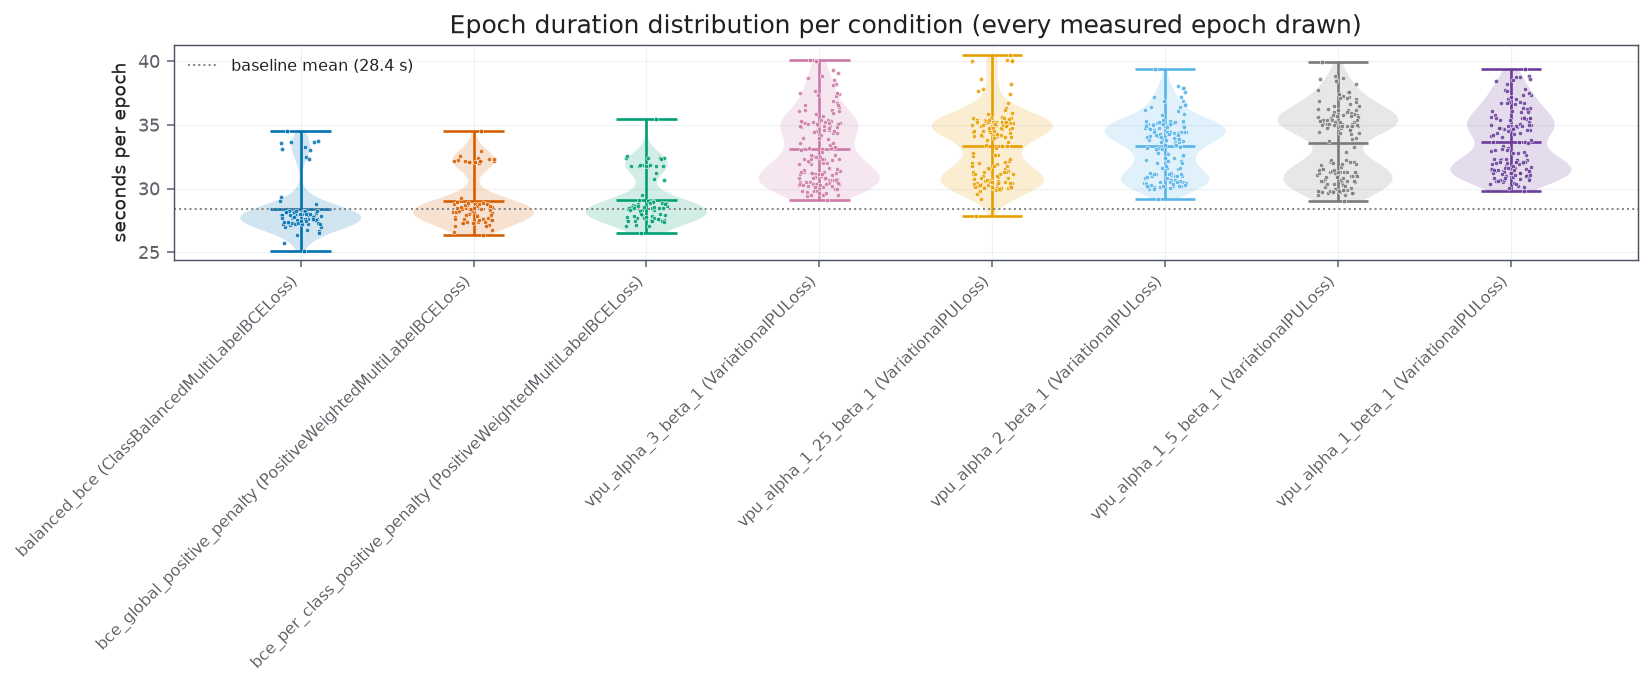

In [8]:
duration_samples = campaign.epoch_duration_samples(dynamics_frame, inventory)
ordered_labels = run_frame.groupby("label")["mean_epoch_duration"].mean().sort_values().index.tolist()

figure, ax = plt.subplots(figsize=(12.0, 5.0), dpi=theme.figure_dpi)
for position, label in enumerate(ordered_labels):
    plot_violin_with_points(
        np.asarray(duration_samples[label]), position=position, ax=ax, width=0.7,
        color=theme.color_for_model(label, position), point_size=5.0, jitter=0.12, theme=theme,
    )
ax.axhline(baseline_epoch_seconds, color="grey", linestyle=":", linewidth=1, label=f"baseline mean ({baseline_epoch_seconds:.1f} s)")
ax.set_xticks(range(len(ordered_labels)))
ax.set_xticklabels(ordered_labels, rotation=45, ha="right", fontsize=8)
ax.set(ylabel="seconds per epoch", title="Epoch duration distribution per condition (every measured epoch drawn)")
ax.grid(theme.grid_visible, alpha=theme.grid_alpha)
ax.legend(fontsize=8, frameon=theme.legend_frame)
figure.tight_layout()

## Reproducible artifacts

### Methodology

#### Implementation

The measured tables and their provenance are written by the precompute runner, not here.
This notebook adds no derived tables of its own beyond a few operations on tables already
in memory. Provenance, including the commit, the device, the seeds and the source hashes
of the analysis modules, lives in the runner's `metadata.json`.

The results directory is deliberately not versioned: it is regenerable from the runner
and its recorded provenance.

### Remarks

### Notes

In [9]:
print("precomputed tables present:", sorted(path.name for path in ARTIFACT_DIR.glob("*.csv")))
print("provenance:", {"analysis": provenance["analysis"], "git_commit": provenance["git_commit"],
                      "device": provenance["settings"]["device"], "planned_epochs": provenance["planned_epochs"],
                      "tasks": provenance["tasks"]})

precomputed tables present: ['condition_coverage.csv', 'final_evaluation.csv', 'inventory.csv', 'run_durations.csv', 'sources.csv', 'training_dynamics.csv', 'training_health.csv']
provenance: {'analysis': 'campaign_training_dynamics', 'git_commit': 'e3b8aef6c9ee49acda5d35c416410af769df41bc', 'device': 'cuda', 'planned_epochs': 15, 'tasks': 65}


## Results / Summary

### LLM

Not yet run against the real campaign cache. This notebook has not been executed against
`data/kidney_workspace`; run the precompute command printed above, then re-populate this
section with the actually observed coverage, health-check outcomes and duration ratios
before treating any interpretation here as verified.

### Person